# Генератор пользовательских данных для подсчета клеток крови

## HT_4:
На основе реализованного генератора, выполнить тренировку нейронной сети resnet для решения задачи подсчета количества клеток на изображении.

Математематическая постановка может решать в виде решения задачи классификации. Номер класса - количество клеток на изображения.
Рекомендуется применять BCELoss.

В качестве target вероятностной метрики использовать распределение в терминах uncertancy, близкое к нормальному.
Пример target-вероятностного вектора для задачи с максимальным количеством клеток равным 10.

Пример для изображения с количеством клеток 7.
[0,0,0,0,0.1,0.5,1.0,0.5,0.1,0]


In [1]:
# Настройка окружения
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import norm
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, List
import torch
import torch.nn as nn
from torchvision import models, transforms
from tqdm.notebook import tqdm

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [2]:
# Гиперпараметры
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MAX_CELLS = 9          # Максимальное количество клеток (классы 0..9)
NUM_CLASSES = MAX_CELLS + 1  # 10 классов
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3
SIGMA = 1.2            # Параметр Гауссова распределения для soft target

TOTAL_DATA = 2000
TRAIN_RATIO = 0.8
TRAIN_SIZE = int(TOTAL_DATA * TRAIN_RATIO)
VAL_SIZE = TOTAL_DATA - TRAIN_SIZE

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Classes: {NUM_CLASSES} (0..{MAX_CELLS})")
print(f"Train: {TRAIN_SIZE}, Val: {VAL_SIZE}")

Device: cuda
Classes: 10 (0..9)
Train: 1600, Val: 400


In [3]:
def load_bccd_patches_to_ram(bccd_img_dir: str, bccd_mask_dir: str, patch_size=64):
    """Загрузка патчей фона и клеток из BCCD датасета."""
    bg_patches, cell_patches = [], []
    
    if not os.path.exists(bccd_img_dir) or not os.path.exists(bccd_mask_dir):
        print("[WARN] Папки BCCD не найдены. Будет использована только синтетика.")
        return bg_patches, cell_patches

    print("Нарезка датасета...")
    mask_files = os.listdir(bccd_mask_dir)
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_name in os.listdir(bccd_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img = cv2.imread(os.path.join(bccd_img_dir, img_name))
        if img is None: continue
        
        base_name = os.path.splitext(img_name)[0]
        if base_name not in mask_dict: continue
            
        mask = cv2.imread(os.path.join(bccd_mask_dir, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        
        _, mask_bin = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        h, w = img.shape[:2]
        step = patch_size // 2 
        
        for y in range(0, h - patch_size + 1, step):
            for x in range(0, w - patch_size + 1, step):
                p_mask = mask_bin[y:y+patch_size, x:x+patch_size]
                p_img = img[y:y+patch_size, x:x+patch_size]
                
                cell_pixels = np.sum(p_mask > 0)
                total_pixels = patch_size * patch_size
                
                if cell_pixels > total_pixels * 0.5:
                    cell_patches.append(p_img.copy())
                elif cell_pixels == 0:
                    bg_patches.append(p_img.copy())
    
    print(f"Загружено: {len(bg_patches)} фонов, {len(cell_patches)} клеток.")
    return bg_patches, cell_patches

In [ ]:
# Загрузка патчей BCCD (если доступны)
bccd_img_dir = "bccd/train/images"
bccd_mask_dir = "bccd/train/masks"

bg_patches_list = []
cell_patches_list = []

if os.path.exists(bccd_img_dir) and os.path.exists(bccd_mask_dir):
    bg_patches_list, cell_patches_list = load_bccd_patches_to_ram(
        bccd_img_dir=bccd_img_dir,
        bccd_mask_dir=bccd_mask_dir,
        patch_size=64
    )
else:
    print("[INFO] BCCD не найден. Используем только синтетику.")

Нарезка датасета...
Загружено: 794246 фонов, 621732 клеток.
Фонов: 794246, Клеток: 621732


In [ ]:
# Демонстрация soft target
def create_soft_target(count, num_classes=10, sigma=1.2):
    """
    Создаёт soft target вектор на основе Гауссова распределения.
    """
    x = np.arange(num_classes)
    pdf = norm.pdf(x, loc=count, scale=sigma)
    target = pdf / pdf.max()
    return target.astype(np.float32)

count=7: [4.0828361e-08 3.7266532e-06 1.6985668e-04 3.8659202e-03 4.3936934e-02
 2.4935220e-01 7.0664829e-01 1.0000000e+00 7.0664829e-01 2.4935220e-01]
count=3: [4.3936934e-02 2.4935220e-01 7.0664829e-01 1.0000000e+00 7.0664829e-01
 2.4935220e-01 4.3936934e-02 3.8659202e-03 1.6985668e-04 3.7266532e-06]
count=9: [6.1019364e-13 2.2336315e-10 4.0828361e-08 3.7266532e-06 1.6985668e-04
 3.8659202e-03 4.3936934e-02 2.4935220e-01 7.0664829e-01 1.0000000e+00]
count=0: [1.0000000e+00 7.0664829e-01 2.4935220e-01 4.3936934e-02 3.8659202e-03
 1.6985668e-04 3.7266532e-06 4.0828361e-08 2.2336315e-10 6.1019364e-13]


In [ ]:
class BloodCellDataset(Dataset):
    """
    Генератор изображений клеток крови для тренировки ResNet.
    
    ВАЖНЫЕ ИЗМЕНЕНИЯ (исправление бага с "фиолетовыми" изображениями):
    - Клетки рисуются на отдельном холсте (cells_img + cells_mask), затем накладываются на фон одной операцией
    - Проверка перекрытия клеток перед размещением (coverage check)
    - Расширенная палитра цветов фона и клеток
    - Тайловый фон из патчей (а не просто resize одного патча)
    - Размер 224x224 (совместимость с ImageNet pretrained weights)
    """
    
    def __init__(
        self,
        img_size: Tuple[int, int] = (224, 224),
        dataset_size: int = 200,
        bg_patches: List[np.ndarray] = None,
        cell_patches: List[np.ndarray] = None,
        min_cells_count: int = 1,
        max_cells_count: int = 9,
        num_classes: int = 10,
        sigma: float = 1.2,
        min_cell_coverage: float = 0.3,
        seed: int = 42
    ):
        super().__init__()
        random.seed(seed)
        np.random.seed(seed)
        
        self.img_size = img_size  # (h, w)
        self.dataset_size = dataset_size
        self.bg_patches = bg_patches if bg_patches else []
        self.cell_patches = cell_patches if cell_patches else []
        self.min_cells_count = min_cells_count
        self.max_cells_count = max_cells_count
        self.num_classes = num_classes
        self.sigma = sigma
        self.min_cell_coverage = min_cell_coverage
        
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self) -> int:
        return self.dataset_size

    def _create_soft_target(self, true_count: int) -> torch.Tensor:
        """Soft target через scipy.stats.norm.pdf."""
        x = np.arange(self.num_classes)
        pdf_vals = norm.pdf(x, loc=true_count, scale=self.sigma)
        target = pdf_vals / pdf_vals.max()
        return torch.tensor(target, dtype=torch.float32)

    def __getitem__(self, idx: int):
        h, w = self.img_size
        
        # Генерация фона 
        clean_img = self._select_background(h, w)
        
        # Размещение клеток на отдельном холсте 
        cells_count = random.randint(self.min_cells_count, self.max_cells_count)
        
        # Холст для всех клеток 
        cells_img = np.zeros((h, w, 3), dtype=np.uint8)
        cells_mask = np.zeros((h, w), dtype=np.uint8)
        
        actual_cells_count = 0
        
        for _ in range(cells_count):
            placed = False
            for _attempt in range(2000):
                # Временные буферы
                temp_img = np.zeros((h, w, 3), dtype=np.uint8)
                temp_mask = np.zeros((h, w), dtype=np.uint8)
                
                # Случайная позиция
                x = random.randint(10, w - 10)
                y = random.randint(10, h - 10)
                
                # Выбор: реальный патч или синтетическая клетка
                if len(self.cell_patches) > 0 and random.random() < 0.5:
                    # Реальный патч клетки
                    patch = random.choice(self.cell_patches)
                    new_size = random.randint(20, 45)
                    patch = cv2.resize(patch, (new_size, new_size))
                    ph, pw = patch.shape[:2]
                    
                    x1 = max(0, x - pw // 2)
                    y1 = max(0, y - ph // 2)
                    x2 = min(w, x1 + pw)
                    y2 = min(h, y1 + ph)
                    
                    # Маска патча (все ненулевые пиксели = клетка)
                    patch_gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
                    _, patch_mask = cv2.threshold(patch_gray, 5, 255, cv2.THRESH_BINARY)
                    
                    temp_mask[y1:y2, x1:x2] = patch_mask[:y2-y1, :x2-x1]
                    temp_img[y1:y2, x1:x2] = patch[:y2-y1, :x2-x1]
                else:
                    # Синтетическая клетка (круг)
                    rad = random.randint(8, 20)
                    color = self._get_cell_color()
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=color, thickness=-1)
                    stroke_color = (min(255, color[0] + 60),
                                   min(255, color[1] + 60),
                                   min(255, color[2] + 60))
                    cv2.circle(temp_img, center=(x, y), radius=rad,
                              color=stroke_color, thickness=2)
                
                # Проверка: не перекрывается ли с уже размещёнными клетками
                overlap_mask = cv2.bitwise_and(temp_mask, cells_mask)
                temp_mask_only = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))
                
                total_new = np.count_nonzero(temp_mask)
                if total_new == 0:
                    continue
                
                coverage = np.count_nonzero(temp_mask_only) / total_new
                
                if coverage >= self.min_cell_coverage:
                    # Размещаем клетку
                    cells_img = self._add_image_with_mask(cells_img, temp_img, temp_mask_only)
                    cells_mask = cv2.bitwise_or(cells_mask, temp_mask)
                    actual_cells_count += 1
                    placed = True
                    break
            
            if not placed:
                pass  # Не удалось разместить клетку, пропускаем
        
        # Наложение клеток на фон 
        clean_img = self._add_image_with_mask(clean_img, cells_img, cells_mask)
        
        # Конвертация в тензор: BGR -> RGB -> float [0,1] -> CHW -> normalize 
        image = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        image = self.normalize(image)
        
        # Soft target
        target = self._create_soft_target(actual_cells_count)
        
        return image, target, actual_cells_count

    def _select_background(self, h: int, w: int) -> np.ndarray:
        """Генерация фона: тилинг патчей или однотонный."""
        if len(self.bg_patches) > 0 and random.random() > 0.3:
            # Тилирование патчей фона
            bg = np.zeros((h, w, 3), dtype=np.uint8)
            patch_size = 128
            for iy in range(0, h, patch_size):
                for ix in range(0, w, patch_size):
                    patch = random.choice(self.bg_patches)
                    patch = cv2.resize(patch, (patch_size, patch_size))
                    h_end = min(iy + patch_size, h)
                    w_end = min(ix + patch_size, w)
                    bg[iy:h_end, ix:w_end] = patch[:h_end-iy, :w_end-ix]
            # Лёгкое размытие для стыков
            bg = cv2.GaussianBlur(bg, (3, 3), 0)
        else:
            # Однотонный фон
            color = [random.randint(180, 240), random.randint(180, 240), random.randint(180, 240)]
            bg = np.full((h, w, 3), color, dtype=np.uint8)
        return bg

    def _get_cell_color(self) -> Tuple[int, int, int]:
        """Случайный цвет клетки (BGR)."""
        return (
            random.randint(100, 220),   # B
            random.randint(80, 200),    # G
            random.randint(80, 200)     # R
        )

    @staticmethod
    def _add_image_with_mask(dst: np.ndarray, src: np.ndarray, mask: np.ndarray) -> np.ndarray:
        """
        Наложение src на dst по маске mask (замена seamlessClone).
        dst[mask > 0] = src[mask > 0]
        """
        result = dst.copy()
        result[mask > 0] = src[mask > 0]
        return result

In [7]:
# Создание датасетов
train_dataset = BloodCellDataset(
    img_size=(224, 224),
    dataset_size=TRAIN_SIZE,
    bg_patches=bg_patches_list,
    cell_patches=cell_patches_list,
    min_cells_count=1,
    max_cells_count=MAX_CELLS,
    num_classes=NUM_CLASSES,
    sigma=SIGMA,
    seed=SEED
)

val_dataset = BloodCellDataset(
    img_size=(224, 224),
    dataset_size=VAL_SIZE,
    bg_patches=bg_patches_list,
    cell_patches=cell_patches_list,
    min_cells_count=1,
    max_cells_count=MAX_CELLS,
    num_classes=NUM_CLASSES,
    sigma=SIGMA,
    seed=SEED + 1
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} изображений, {len(train_loader)} батчей")
print(f"Val:   {len(val_dataset)} изображений, {len(val_loader)} батчей")

Train: 1600 изображений, 50 батчей
Val:   400 изображений, 13 батчей


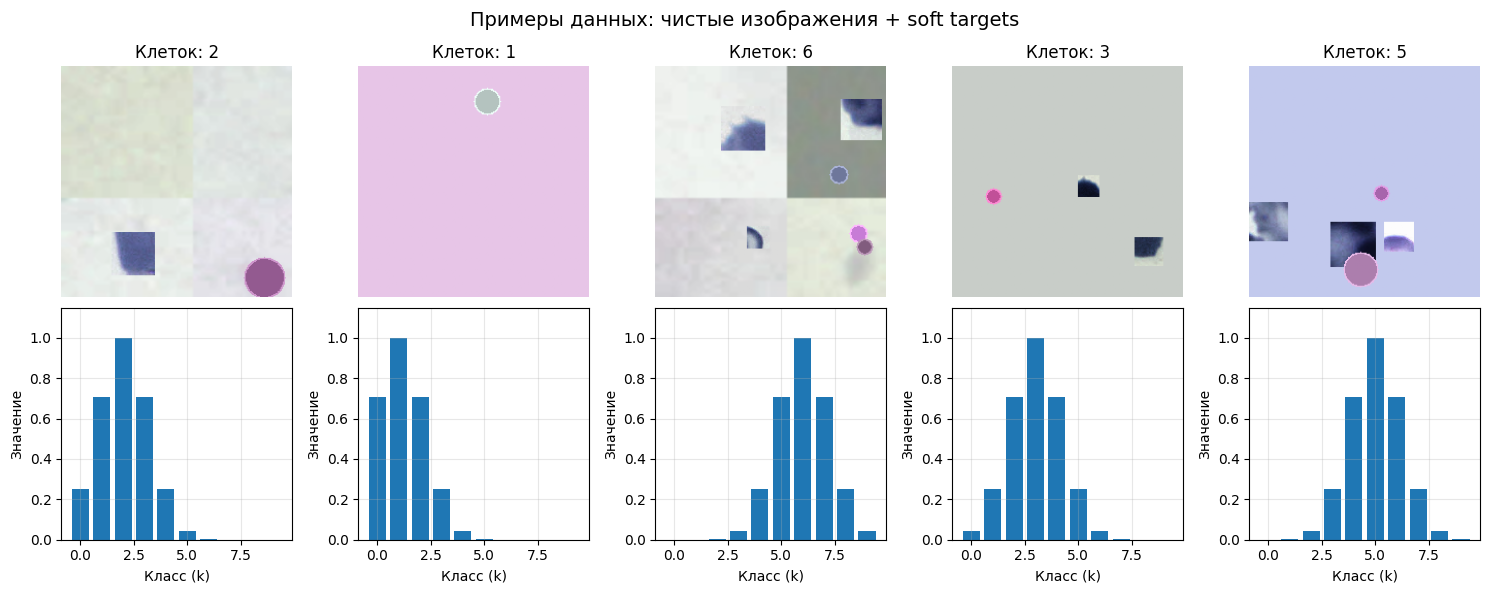

In [11]:
# Визуализация примеров (изображения до нормализации для наглядности)
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Примеры данных: чистые изображения + soft targets", fontsize=14)

for i in range(5):
    img, target, count = train_dataset[i]
    
    # Денормализация для отображения
    img_np = denormalize(img).permute(1, 2, 0).numpy()
    
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"Клеток: {count}")
    axes[0, i].axis('off')
    
    axes[1, i].bar(range(NUM_CLASSES), target.numpy())
    axes[1, i].set_xlabel("Класс (k)")
    axes[1, i].set_ylabel("Значение")
    axes[1, i].set_ylim(0, 1.15)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

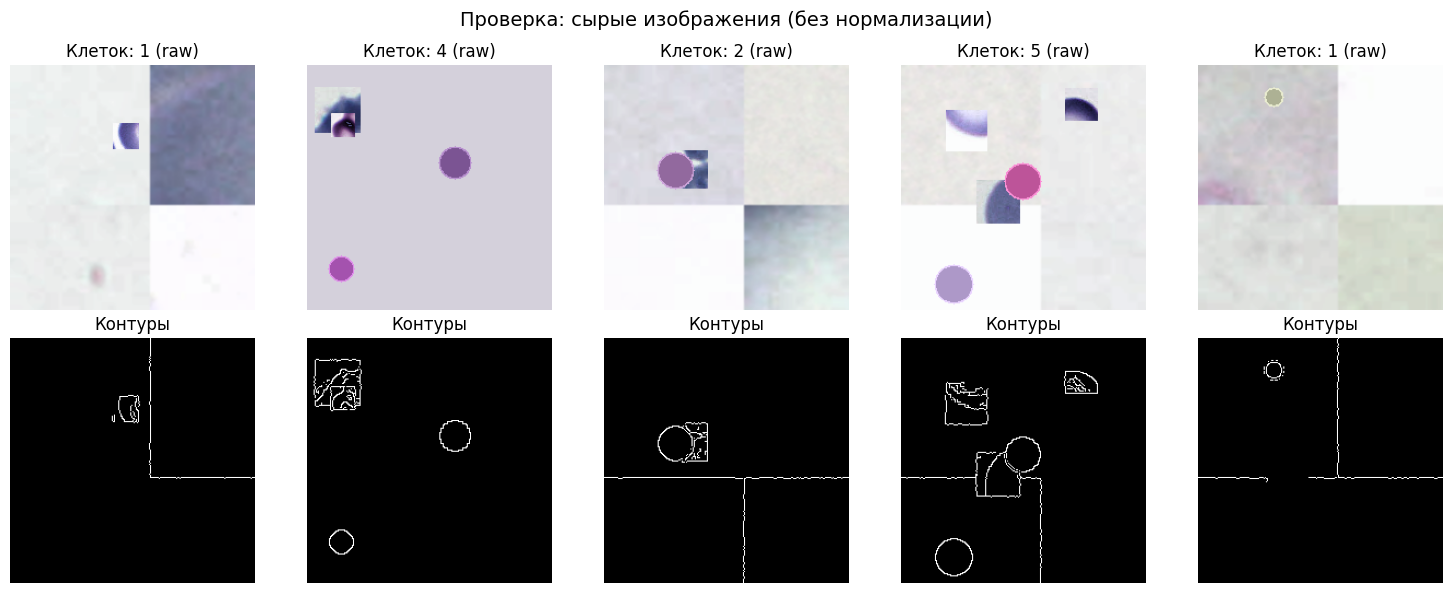

In [12]:
# Визуализация СЫРЫХ изображений (без нормализации) — проверка генерации
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Проверка: сырые изображения (без нормализации)", fontsize=14)

for i in range(5):
    img, target, count = train_dataset[i]
    
    # Обратное преобразование: undo normalization, convert to uint8
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * std + mean)
    img_uint8 = np.clip(img_np * 255, 0, 255).astype(np.uint8)
    
    # Подсветка клеток через поиск контуров
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 30, 100)
    
    axes[0, i].imshow(img_uint8)
    axes[0, i].set_title(f"Клеток: {count} (raw)")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(edges, cmap='gray')
    axes[1, i].set_title("Контуры")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ResNet18: Linear(512 -> 10) 
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"Обучаемых: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Параметров: 11,181,642
Обучаемых: 11,181,642


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [15]:
def train_step(model, loss_function, optimizer, image, target):
    """Один шаг обучения."""
    model.train()
    optimizer.zero_grad()
    prediction = model(image)
    loss = loss_function(prediction, target)
    loss.backward()
    optimizer.step()
    return loss.item()

In [16]:
@torch.no_grad()
def accuracy(model, image, true_counts):
    """Точность: argmax(prediction) == true_count."""
    model.eval()
    prediction = model(image)
    _, argmaxes = prediction.max(-1)
    is_correct = (argmaxes == true_counts.int().squeeze()).cpu().numpy().tolist()
    return is_correct

In [17]:
@torch.no_grad()
def validation_loss(model, loss_function, image, target):
    """Loss на валидации."""
    model.eval()
    prediction = model(image)
    loss = loss_function(prediction, target)
    return loss.item()

In [ ]:
# Training loop
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
best_model_state = None

print("=" * 60)
print("Начало тренировки")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"Epoch: {epoch + 1}")
    
    # Train loss
    train_epoch_losses = []
    for idx, (image, target, true_count) in enumerate(train_loader):
        image = image.to(DEVICE)
        target = target.to(DEVICE)
        loss = train_step(model, criterion, optimizer, image, target)
        train_epoch_losses.append(loss)
        if (idx + 1) % 10 == 0:
            print(loss)
    
    train_epoch_loss = np.mean(train_epoch_losses)
    print(f"Train Loss: {train_epoch_loss:.4f}")
    train_losses.append(train_epoch_loss)
    
    # Train accuracy (отдельный проход)
    train_epoch_accuracies = []
    for idx, (image, target, true_count) in enumerate(train_loader):
        image = image.to(DEVICE)
        true_count = true_count.to(DEVICE)
        is_correct = accuracy(model, image, true_count)
        train_epoch_accuracies.extend(is_correct)
    
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    print(f"Train Accuracy: {train_epoch_accuracy * 100:.2f}%")
    train_accuracies.append(train_epoch_accuracy)
    
    # Validation loss и accuracy
    val_epoch_losses = []
    val_epoch_accuracies = []
    for idx, (image, target, true_count) in enumerate(val_loader):
        image = image.to(DEVICE)
        target = target.to(DEVICE)
        true_count = true_count.to(DEVICE)
        
        loss = validation_loss(model, criterion, image, target)
        val_epoch_losses.append(loss)
        is_correct = accuracy(model, image, true_count)
        val_epoch_accuracies.extend(is_correct)
    
    val_epoch_loss = np.mean(val_epoch_losses)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    print(f"Val Loss: {val_epoch_loss:.4f}")
    print(f"Val Accuracy: {val_epoch_accuracy * 100:.2f}%")
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)
    
    # Сохранение лучшей модели
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        best_model_state = model.state_dict().copy()
        print(f"  -> Новая лучшая модель! Val Loss: {best_val_loss:.4f}")
    
    scheduler.step()
    print("-" * 40)

print("=" * 60)
print(f"Лучшая Val Loss: {best_val_loss:.4f}")
print("=" * 60)

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Лучшая модель загружена.")

Начало тренировки
Epoch: 1
0.4381479322910309
0.5618244409561157
0.368780255317688
0.32543665170669556
0.372285932302475
Train Loss: 0.4104
Train Accuracy: 22.81%
Val Loss: 1.3020
Val Accuracy: 21.00%
  -> Новая лучшая модель! Val Loss: 1.3020
----------------------------------------
Epoch: 2
0.36452969908714294
0.3429470658302307
0.3385500907897949
0.30647143721580505
0.33245986700057983
Train Loss: 0.3453
Train Accuracy: 54.50%
Val Loss: 0.3096
Val Accuracy: 54.00%
  -> Новая лучшая модель! Val Loss: 0.3096
----------------------------------------
Epoch: 3
0.40887507796287537
0.2922726273536682
0.39139318466186523
0.37879642844200134
0.3536887764930725
Train Loss: 0.3301
Train Accuracy: 41.50%
Val Loss: 0.5904
Val Accuracy: 35.25%
----------------------------------------
Epoch: 4
0.33206474781036377
0.32457295060157776
0.29366156458854675
0.32070907950401306
0.3025016486644745
Train Loss: 0.3093
Train Accuracy: 65.69%
Val Loss: 0.3085
Val Accuracy: 65.00%
  -> Новая лучшая модель! Va

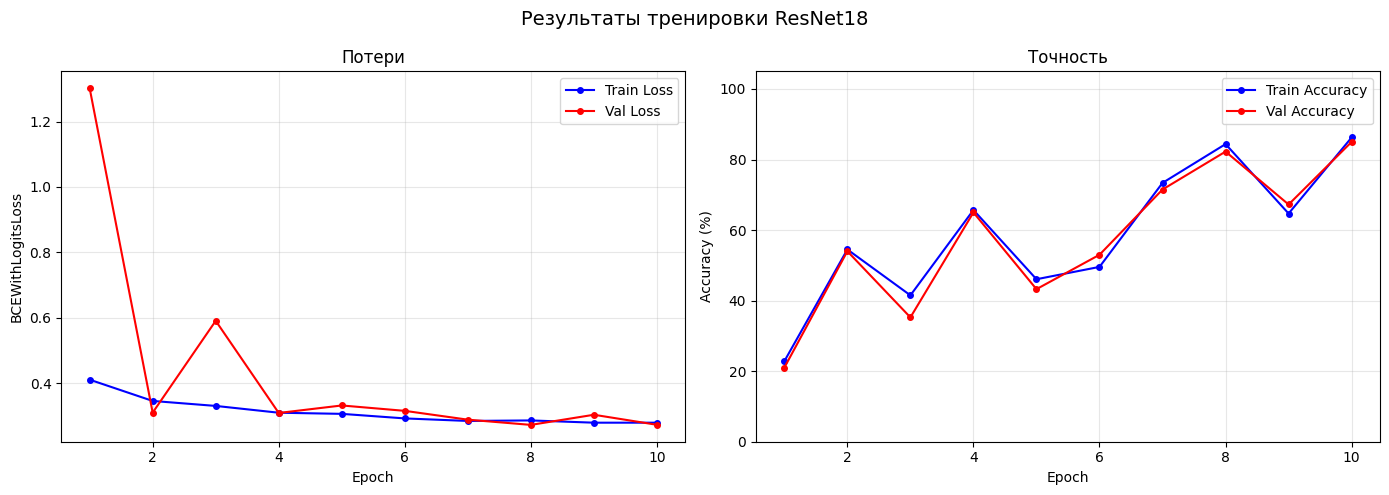

In [19]:
# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Train Loss', markersize=4)
axes[0].plot(range(1, EPOCHS+1), val_losses, 'r-o', label='Val Loss', markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCEWithLogitsLoss")
axes[0].set_title("Потери")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(range(1, EPOCHS+1), [a*100 for a in train_accuracies], 'b-o', 
            label='Train Accuracy', markersize=4)
axes[1].plot(range(1, EPOCHS+1), [a*100 for a in val_accuracies], 'r-o', 
            label='Val Accuracy', markersize=4)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Точность")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 105)

plt.suptitle("Результаты тренировки ResNet18", fontsize=14)
plt.tight_layout()
plt.show()

True:  8 | Pred:  7
True:  7 | Pred:  7
True:  5 | Pred:  5
True:  1 | Pred:  1
True:  6 | Pred:  6
True:  1 | Pred:  1
True:  1 | Pred:  1
True:  8 | Pred:  8
True:  4 | Pred:  4
True:  5 | Pred:  5


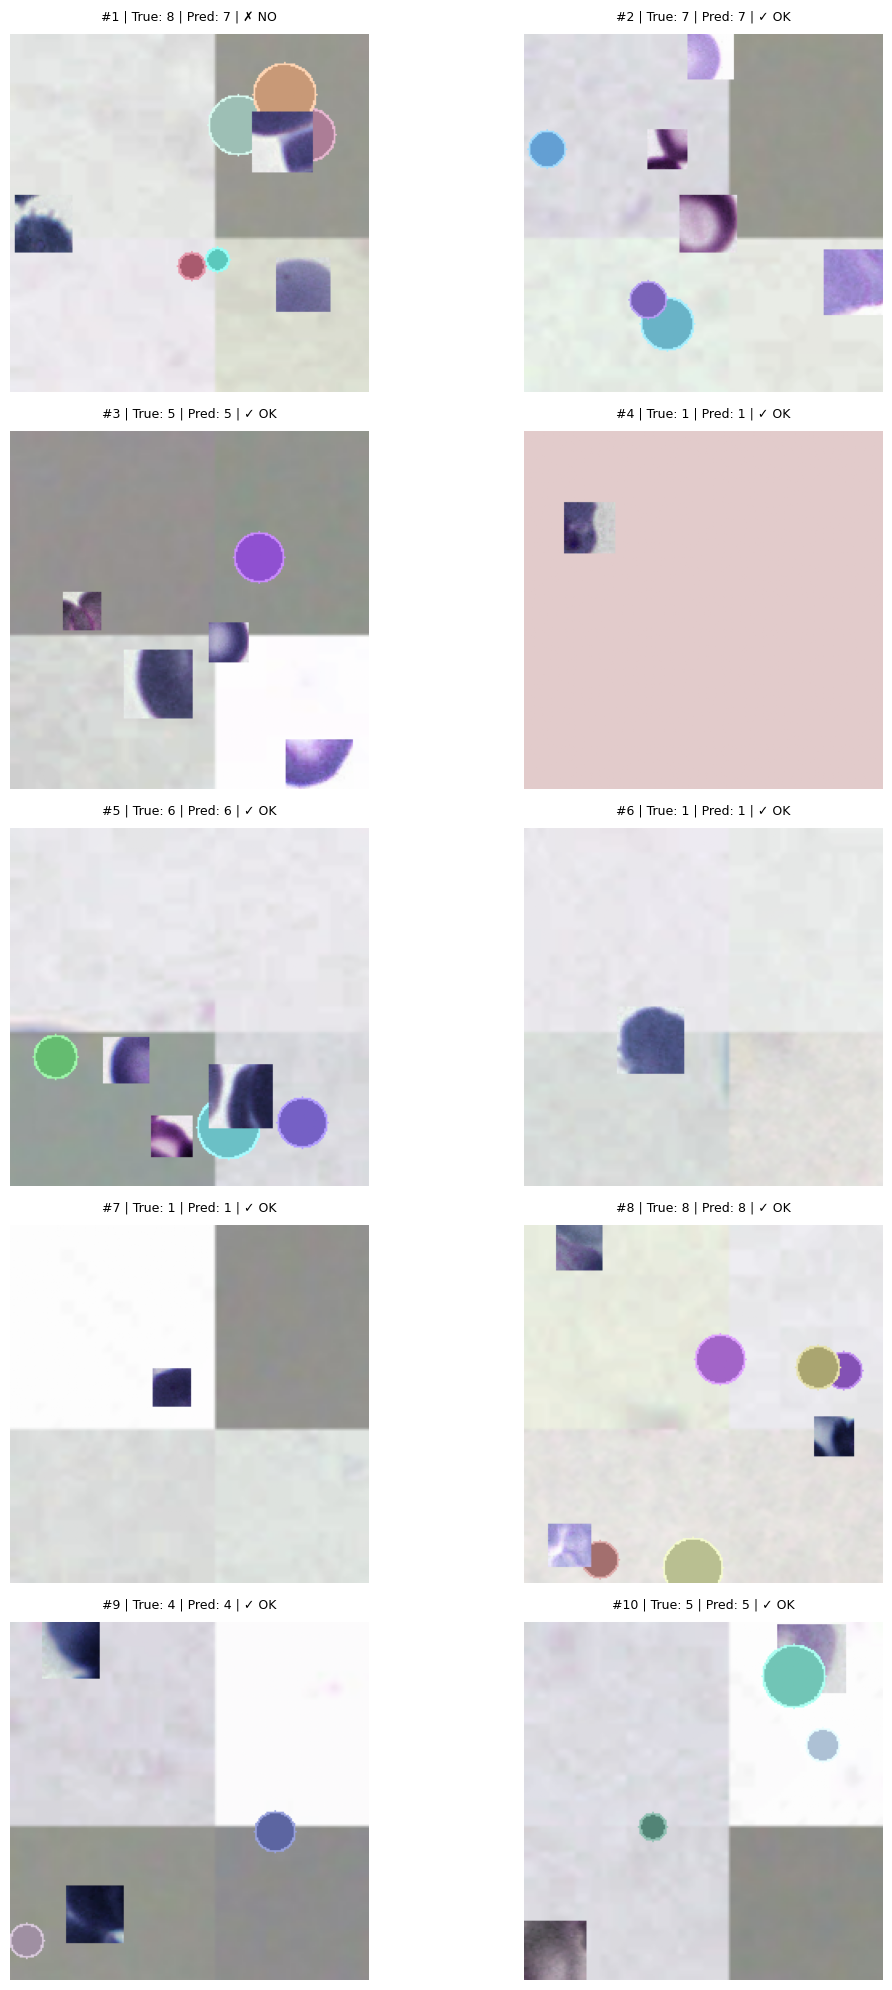

In [20]:
# Визуализация предсказаний
model.eval()

results = []
with torch.no_grad():
    for i in range(10):
        img, target, true_c = val_dataset[random.randint(0, len(val_dataset) - 1)]
        logits = model(img.unsqueeze(0).to(DEVICE))
        probs = torch.softmax(logits, dim=1)[0]
        pred_class = torch.argmax(probs).item()
        results.append((img, target, true_c, pred_class, probs.cpu()))
        print(f"True: {true_c:2d} | Pred: {pred_class:2d}")

fig, axes = plt.subplots(5, 2, figsize=(12, 20))
for i in range(10):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    img, target, true_c, pred_class, probs = results[i]
    img_d = denormalize(img)
    img_d = np.clip(img_d.numpy().transpose(1, 2, 0), 0, 1)
    
    ax.imshow(img_d)
    ok = '✓ OK' if pred_class == true_c else '✗ NO'
    ax.set_title(f"#{i+1} | True: {true_c} | Pred: {pred_class} | {ok}", fontsize=9, pad=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

Финальная точность: 80.0%
Финальная MAE:     0.20 клеток


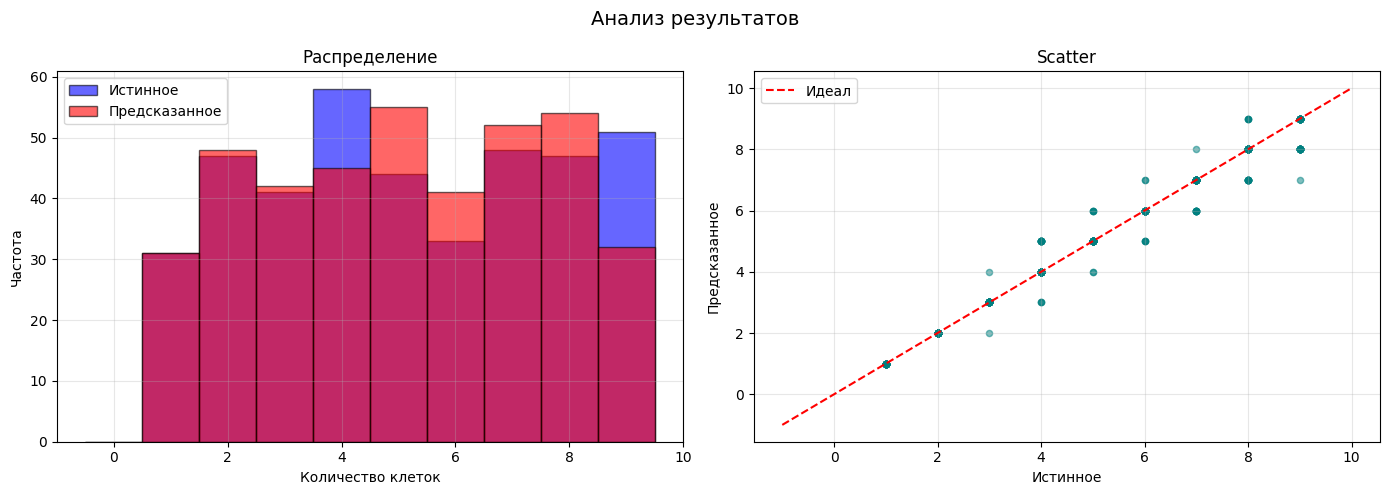

In [21]:
# Детальный анализ
model.eval()

all_pred = []
all_true = []

with torch.no_grad():
    for images, targets, counts in val_loader:
        images = images.to(DEVICE)
        preds = model(images)
        pred_counts = preds.argmax(dim=1).cpu().numpy()
        true_counts = counts.numpy()
        all_pred.extend(pred_counts.tolist())
        all_true.extend(true_counts.tolist())

all_pred = np.array(all_pred)
all_true = np.array(all_true)

final_acc = np.mean(all_pred == all_true)
final_mae = np.mean(np.abs(all_pred - all_true))
print(f"Финальная точность: {final_acc*100:.1f}%")
print(f"Финальная MAE:     {final_mae:.2f} клеток")

# Гистограмма + scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(-0.5, NUM_CLASSES + 0.5)
axes[0].hist(all_true, bins=bins, alpha=0.6, label='Истинное', color='blue', edgecolor='black')
axes[0].hist(all_pred, bins=bins, alpha=0.6, label='Предсказанное', color='red', edgecolor='black')
axes[0].set_xlabel("Количество клеток")
axes[0].set_ylabel("Частота")
axes[0].set_title("Распределение")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(all_true, all_pred, alpha=0.5, s=20, c='teal')
axes[1].plot([-1, NUM_CLASSES], [-1, NUM_CLASSES], 'r--', label='Идеал')
axes[1].set_xlabel("Истинное")
axes[1].set_ylabel("Предсказанное")
axes[1].set_title("Scatter")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Анализ результатов", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Сохранение модели
model_dir = "./models/"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "cell_count_resnet18.pth")
torch.save(model.state_dict(), model_path)
print(f"Модель сохранена: {model_path}")

In [ ]:
# Пример загрузки модели
# loaded_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# loaded_model.fc = nn.Linear(loaded_model.fc.in_features, NUM_CLASSES)
# loaded_model.load_state_dict(torch.load(model_path, weights_only=True))
# loaded_model = loaded_model.to(DEVICE)
# print("Модель загружена.")

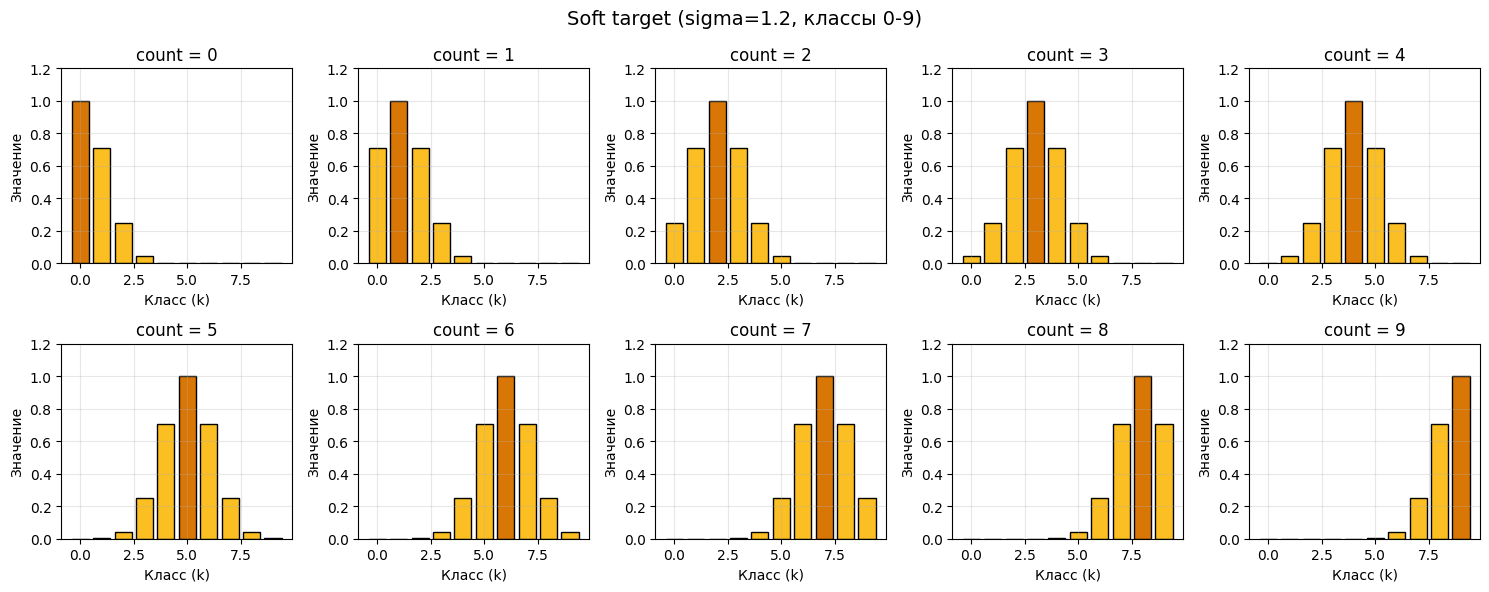

In [22]:
# Демонстрация soft target для всех классов
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f"Soft target (sigma={SIGMA}, классы 0-{MAX_CELLS})", fontsize=14)

for i in range(NUM_CLASSES):
    row = i // 5
    col = i % 5
    target = create_soft_target(i, NUM_CLASSES, SIGMA)
    
    colors = ['#d97706' if v >= 0.99 else '#fbbf24' for v in target]
    axes[row, col].bar(range(NUM_CLASSES), target, color=colors, edgecolor='black')
    axes[row, col].set_title(f"count = {i}")
    axes[row, col].set_xlabel("Класс (k)")
    axes[row, col].set_ylabel("Значение")
    axes[row, col].set_ylim(0, 1.2)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()